# Homework 1

This file contains the solutions to the computational problems in Homework 1 from MATH 5750 taught by Braxton Osting during the Fall 2026 semester.

Import necessary packages, load dataset, and set random seed

In [125]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error
import math

pd.set_option("display.precision", 3)

### Problem 5(a)

In [2]:
df = load_diabetes(as_frame=True, scaled=False).frame

SEED = 0
np.random.seed(SEED)

Define train/test split

In [3]:
X = df.drop(columns='target').values
y = df.target.values
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=100, random_state=SEED)

(a) First we want to analyze the shape of the dataset and create two figures

In [4]:
print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.860,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.892,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.673,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.890,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.290,80.0,135.0


Confirm that there are no missing values.

In [5]:
df.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Describe the dataset using multiple characteristics

In [6]:
df[["bmi","target","bp"]].describe()

,bmi,target,bp
count,442.000,442.000,442.000
mean,26.376,152.133,94.647
std,4.418,77.093,13.831
min,18.000,25.000,62.000
25%,23.200,87.000,84.000
50%,25.700,140.500,93.000
75%,29.275,211.500,105.000
max,42.200,346.000,133.000


In [7]:
df[["bmi","target","bp"]].corr()

,bmi,target,bp
bmi,1.000,0.586,0.395
target,0.586,1.000,0.441
bp,0.395,0.441,1.000


Make a histogram and scatter plot as directed

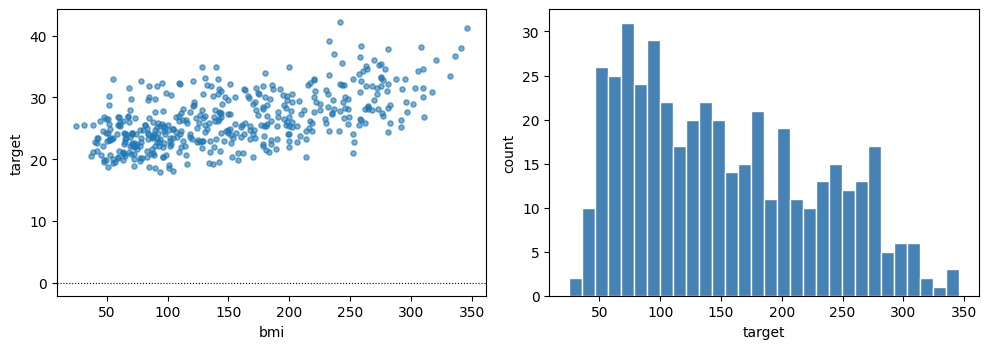

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(df.target, df.bmi, s=14, alpha=0.6)
ax[0].axhline(0, color="k", lw=0.8, ls=":")
ax[0].set_xlabel("bmi"); ax[0].set_ylabel("target")
ax[1].hist(df.target, bins=30, color="steelblue", edgecolor="w")
ax[1].set_xlabel("target"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

### Problem 5(b)

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math

results = []

for d in [1, 2, 3]:
    model = make_pipeline(
        PolynomialFeatures(degree=d),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(Xtr, ytr)
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    p = math.comb(Xtr.shape[1] + d, d)
    results.append({
        "degree": d,
        "p": p,
        "training_MSE": mean_squared_error(ytr, train_pred),
        "test_MSE": mean_squared_error(yte, test_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 degree   p  training_MSE  test_MSE
      1  11     2.429e+03  3170.184
      2  66     7.733e+02 22440.791
      3 286     7.301e-24 36205.294


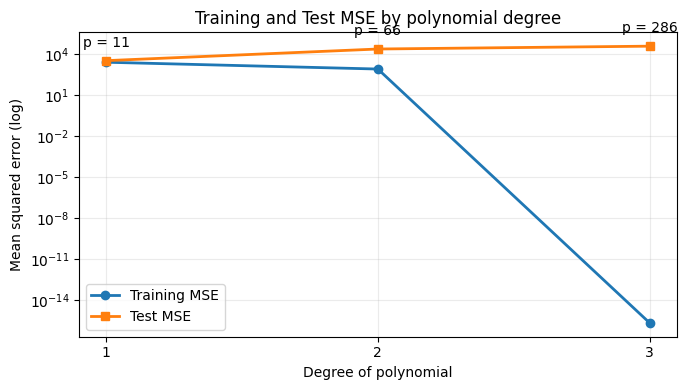

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

degrees = results_df["degree"].to_numpy()
train_mse = results_df["training_MSE"].to_numpy()
test_mse = results_df["test_MSE"].to_numpy()

plot_floor = np.finfo(float).eps

ax.plot(
    degrees,
    np.maximum(train_mse, plot_floor),
    marker="o",
    linewidth=2,
    label="Training MSE"
)

ax.plot(
    degrees,
    np.maximum(test_mse, plot_floor),
    marker="s",
    linewidth=2,
    label="Test MSE"
)

for d, p, train_err, test_err in zip(
    degrees, results_df["p"], train_mse, test_mse
):
    ax.annotate(
        f"p = {p}",
        (d, max(train_err, test_err, plot_floor)),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

ax.set_xticks([1, 2, 3])
ax.set_xlabel("Degree of polynomial")
ax.set_ylabel("Mean squared error (log)")
ax.set_yscale("log")
ax.set_title("Training and Test MSE by polynomial degree")
ax.grid(True, which="both", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Problem 5(c)

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

lams = np.logspace(-4, 4, 60)

folds = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_mse = []
cv_mse = []

for lam in lams:
    ridge_model = make_pipeline(
        PolynomialFeatures(degree=2),
        StandardScaler(),
        Ridge(alpha=lam)
    )

    fold_scores = cross_val_score(
        ridge_model,
        Xtr,
        ytr,
        cv=folds,
        scoring="neg_mean_squared_error"
    )

    cv_mse.append(-fold_scores.mean())

    ridge_model.fit(Xtr, ytr)
    train_pred = ridge_model.predict(Xtr)
    train_mse.append(mean_squared_error(ytr, train_pred))

train_mse = np.array(train_mse)
cv_mse = np.array(cv_mse)

In [21]:
best_index = np.argmin(cv_mse)
best_lam = lams[best_index]
best_cv_mse = cv_mse[best_index]

print(f"Selected lambda: {best_lam:.6g}")
print(f"Cross-validated MSE: {best_cv_mse:.6g}")

Selected lambda: 92.4915
Cross-validated MSE: 2940.07


In [22]:
best_ridge_model = make_pipeline(
    PolynomialFeatures(degree=2),
    StandardScaler(),
    Ridge(alpha=best_lam)
)

best_ridge_model.fit(Xtr, ytr)

best_train_mse = mean_squared_error(
    ytr,
    best_ridge_model.predict(Xtr)
)

best_test_mse = mean_squared_error(
    yte,
    best_ridge_model.predict(Xte)
)

print(f"Training MSE at selected lambda: {best_train_mse:.6g}")
print(f"Test MSE at selected lambda:     {best_test_mse:.6g}")

Training MSE at selected lambda: 2480.02
Test MSE at selected lambda:     3061.07


In [35]:
test_mse = []

for lam in lams:
    model = make_pipeline(
        PolynomialFeatures(degree=2),
        StandardScaler(),
        Ridge(alpha=lam)
    )

    model.fit(Xtr, ytr)
    test_mse.append(
        mean_squared_error(yte, model.predict(Xte))
    )

test_mse = np.array(test_mse)

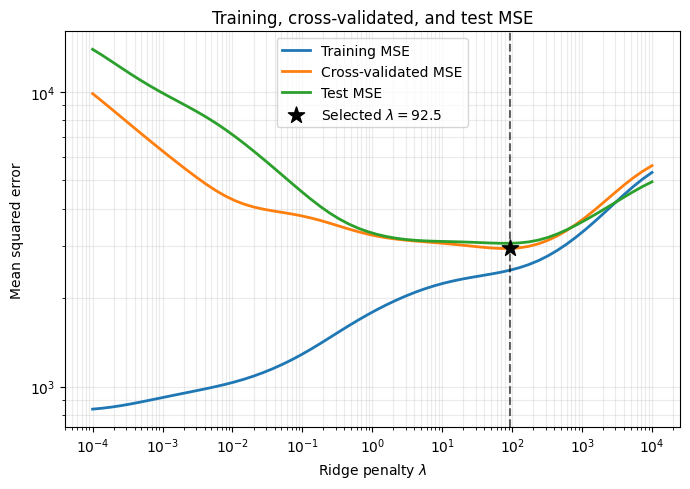

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(lams, train_mse, linewidth=2, label="Training MSE")
ax.plot(lams, cv_mse, linewidth=2, label="Cross-validated MSE")
ax.plot(lams, test_mse, linewidth=2, label="Test MSE")

ax.scatter(
    best_lam,
    best_cv_mse,
    color="black",
    marker="*",
    s=150,
    zorder=3,
    label=fr"Selected $\lambda={best_lam:.3g}$"
)

ax.axvline(best_lam, color="black", linestyle="--", alpha=0.6)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Ridge penalty $\lambda$")
ax.set_ylabel("Mean squared error")
ax.set_title("Training, cross-validated, and test MSE")
ax.grid(True, which="both", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Problem 5(d)

In [ ]:
from sklearn.neural_network import MLPRegressor

net = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64,),
        activation="relu",
        max_iter=20000,
        random_state=SEED
    )
)

net.fit(Xtr, ytr)

train_predictions = net.predict(Xtr)
test_predictions = net.predict(Xte)

net_train_mse = mean_squared_error(ytr, train_predictions)
net_test_mse = mean_squared_error(yte, test_predictions)

print(f"Neural-network training MSE: {net_train_mse:.6f}")
print(f"Neural-network test MSE:     {net_test_mse:.6f}")

Neural-network training MSE: 0.041051
Neural-network test MSE:     8470.762231


### Problem 6(a)

In [87]:
from sklearn.datasets import load_iris
import seaborn as sns

df = load_iris(as_frame=True).frame
#df = sns.load_dataset("iris")

In [88]:
print(df.shape)
df.head()

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [78]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [80]:
df.target.value_counts()
df.groupby("target").mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


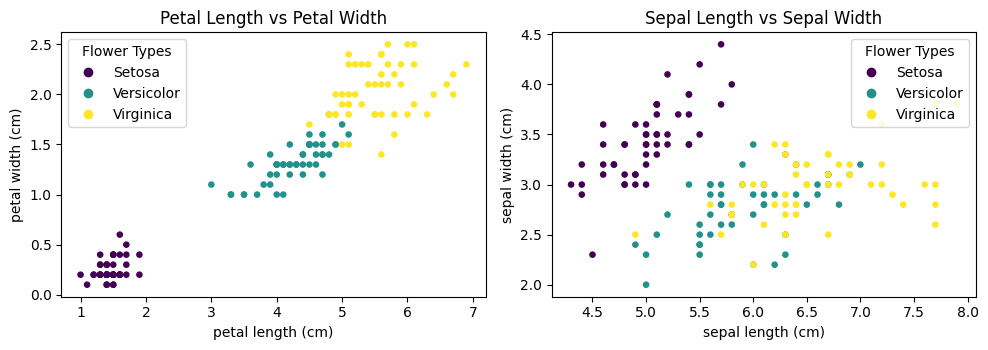

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(df["petal length (cm)"], df["petal width (cm)"], s=14, alpha=1, c=df.target)
ax[0].set_xlabel("petal length (cm)"); ax[0].set_ylabel("petal width (cm)")
ax[0].set_title("Petal Length vs Petal Width")
#ax[0].legend(df["target"], loc="lower right", title="Flower Types")
ax[0].legend(handles=ax[0].collections[0].legend_elements()[0], labels=["Setosa", "Versicolor", "Virginica"], title="Flower Types")
ax[1].scatter(df["sepal length (cm)"], df["sepal width (cm)"], s=14, alpha=1, c=df.target)
ax[1].set_xlabel("sepal length (cm)"); ax[1].set_ylabel("sepal width (cm)")
ax[1].set_title("Sepal Length vs Sepal Width")
ax[1].legend(handles=ax[0].collections[0].legend_elements()[0], labels=["Setosa", "Versicolor", "Virginica"], title="Flower Types")
plt.tight_layout(); plt.show()

### Problem 6(b)

In [ ]:
df_2 = df[["petal length (cm)","petal width (cm)","target"]]
df_restricted_0 = df_2.loc[(df_2['target'] == 0)]
df_restricted_1 = df_2.loc[(df_2['target'] == 1)]
df_restricted = pd.concat([df_restricted_0,df_restricted_1],ignore_index=True)
#df_restricted

,petal length (cm),petal width (cm),target
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0
...,...,...,...
95,4.2,1.2,1
96,4.2,1.3,1
97,4.3,1.3,1
98,3.0,1.1,1


In [136]:
print(df_restricted.iloc[:,[0,1]])

    petal length (cm)  petal width (cm)
0                 1.4               0.2
1                 1.4               0.2
2                 1.3               0.2
3                 1.5               0.2
4                 1.4               0.2
..                ...               ...
95                4.2               1.2
96                4.2               1.3
97                4.3               1.3
98                3.0               1.1
99                4.1               1.3

[100 rows x 2 columns]


In [144]:
C = np.logspace(-2, 6, 25)
beta_norms = []

for c in C:
    model = LogisticRegression(
        C=c,
        penalty="l2",
        solver="lbfgs",
        max_iter=10000,
        tol=1e-10
    )
    model.fit(df_restricted.iloc[:,[0,1]],df_restricted.iloc[:,[2]])
    beta = model.coef_.ravel()
    beta_norms.append(np.linalg.norm(beta, ord=2))

#model.fit(df_restricted.iloc[:,[0,1]],df_restricted.iloc[:,[2]])

# beta = model.coef_.ravel()
# beta_norms.append(np.linalg.norm(beta, ord=2))

beta_norms = np.array(beta_norms)

c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

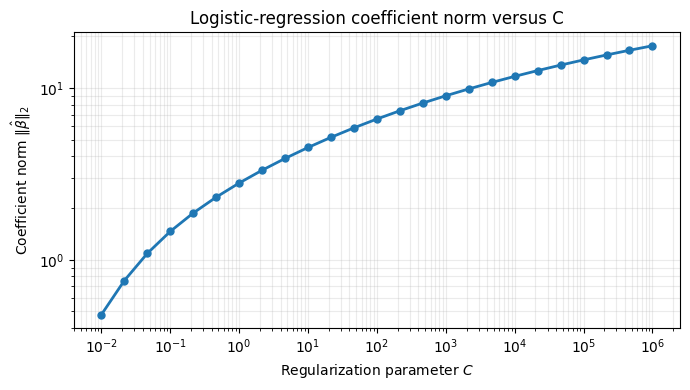

In [146]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    C,
    beta_norms,
    marker="o",
    linewidth=2,
    markersize=5
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Regularization parameter $C$")
ax.set_ylabel(r"Coefficient norm $\|\hat{\beta}\|_2$")
ax.set_title("Logistic-regression coefficient norm versus C")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

### Problem 6(c)

In [147]:
df_2 = df[["sepal length (cm)","sepal width (cm)", "target"]]
df_restricted_1 = df_2.loc[(df_2['target'] == 1)]
df_restricted_2 = df_2.loc[(df_2['target'] == 2)]
df_restricted = pd.concat([df_restricted_1,df_restricted_2],ignore_index=True)
df_restricted

,sepal length (cm),sepal width (cm),target
0,7.0,3.2,1
1,6.4,3.2,1
2,6.9,3.1,1
3,5.5,2.3,1
4,6.5,2.8,1
...,...,...,...
95,6.7,3.0,2
96,6.3,2.5,2
97,6.5,3.0,2
98,6.2,3.4,2
